# FMSR Class 4 – Descriptive Statistics
**Minor Data Driven Decision Making in Business – uitwerking van de opdrachten**

In dit notebook staan de opdrachten uit de slides van Class 4:

1. Exercise Descriptives 3DMiB-minor group (1) – slide 11
2. Exercise Descriptives 3DMiB-minor group (2) – slide 19
3. Exercise Coefficient of Variation – slide 25 (`exercise_coefficient_of_variation.py`)
4. Exercise Olympic Athletes – slide 33

Alle code komt uit de slides en het CV-script. Bij elke stap staat welke slide erbij hoort.

## Data inladen

We gebruiken `minor_survey.xlsx` (Brightspace, FMSR Class 4). Het bestand moet in dezelfde map staan als dit notebook.
`len(data)` telt hoeveel rijen (studenten) er in de data zitten (slide 10).

In [1]:
import numpy as np
import pandas as pd

data = pd.read_excel('minor_survey.xlsx')

# How many rows are in my data? (slide 10)
length_dataframe = len(data)
print(length_dataframe)

print(data)

24
    survey_id han_student programming_language  statistics_proficiency  \
0           1          no               python                     2.0   
1           2         yes               python                     2.0   
2           3         yes               python                     NaN   
3           4         yes               python                     1.0   
4           5          no               python                     2.0   
5           6         yes               python                     2.0   
6           7          no               python                     3.0   
7           8         yes               python                     1.0   
8           9         yes               python                     2.0   
9          10         yes               python                     2.0   
10         11         yes               python                     2.0   
11         12         yes               python                     3.0   
12         13         yes          

**Wat zien we:** er zijn 24 studenten. De kolommen zijn:
- `han_student` en `programming_language`: **categorisch** (tekst)
- `statistics_proficiency`: een **score van 1 t/m 5**. Bij student 3 ontbreekt deze (`NaN`).
- `expected_grade` en `length`: **numeriek**

Voor categorische data gebruiken we frequentie, proportie en modus (slide 9). Voor numerieke data gebruiken we mean en median (slide 8).

---
# Exercise Descriptives (1) – slide 11

## A) Maten van centrale tendens

### Categorische data: frequentie, proportie, modus (slide 9)

- **Frequency:** hoe vaak komt een categorie voor → `value_counts()`
- **Proportion:** het percentage van de keren dat een categorie voorkomt → `value_counts(normalize=True)`
- **Mode:** de categorie die het vaakst voorkomt. Dat is de bovenste regel van `value_counts()`.

**han_student**

In [2]:
frequencies = data['han_student'].value_counts()
proportion = data['han_student'].value_counts(normalize=True)

print(frequencies)
print(proportion)

han_student
yes    20
no      4
Name: count, dtype: int64
han_student
yes    0.833333
no     0.166667
Name: proportion, dtype: float64


**programming_language**

In [3]:
frequencies = data['programming_language'].value_counts()
proportion = data['programming_language'].value_counts(normalize=True)

print(frequencies)
print(proportion)

programming_language
python    23
r          1
Name: count, dtype: int64
programming_language
python    0.958333
r         0.041667
Name: proportion, dtype: float64


**statistics_proficiency**

In [4]:
frequencies = data['statistics_proficiency'].value_counts()
proportion = data['statistics_proficiency'].value_counts(normalize=True)

print(frequencies)
print(proportion)

statistics_proficiency
2.0    10
1.0     6
3.0     4
4.0     2
5.0     1
Name: count, dtype: int64
statistics_proficiency
2.0    0.434783
1.0    0.260870
3.0    0.173913
4.0    0.086957
5.0    0.043478
Name: proportion, dtype: float64


**Wat zien we:**
- **han_student:** 20 keer *yes* (83%) en 4 keer *no* (17%). Modus = **yes**.
- **programming_language:** 23 keer *python* (96%) en 1 keer *r* (4%). Modus = **python**.
- **statistics_proficiency:** score 2 komt het vaakst voor (10 keer, 43%). Modus = **2**. Daarna volgen score 1 (6 keer), 3 (4 keer), 4 (2 keer) en 5 (1 keer). Deze telling gaat over 23 studenten, omdat er één waarde ontbreekt.

### Numerieke data: mean en median (slide 8)

- **Mean:** het gemiddelde → `np.mean()`
- **Median:** het middelste getal van de gesorteerde data → `np.median()`
- `np.median()` kan niet met ontbrekende data omgaan. Daarom zetten we `.dropna()` achter de kolom (slide 8).

**expected_grade**

In [5]:
mean = np.mean(data['expected_grade'])
median = np.median(data['expected_grade'])

print(mean)
print(median)

7.3125
7.0


**length**

In [6]:
mean = np.mean(data['length'])
median = np.median(data['length'])

print(mean)
print(median)

177.79166666666666
180.0


**statistics_proficiency** (met `.dropna()` vanwege de ontbrekende waarde)

In [7]:
mean = np.mean(data['statistics_proficiency'].dropna())
median = np.median(data['statistics_proficiency'].dropna())

print(mean)
print(median)

2.217391304347826
2.0


**Wat zien we:**

| Variabele | Mean | Median |
|---|---|---|
| expected_grade | 7,31 | 7,0 |
| length | 177,79 cm | 180 cm |
| statistics_proficiency | 2,22 | 2,0 |

## B) Mean of median: wat is beter? (slide 12–14 en 18)

Volgens de slides:
- Het antwoord hangt af van de data (slide 12).
- De **mean** is gevoelig voor uitschieters, de **median** niet (slide 12–13).
- De mean wordt het meest gebruikt, **behalve** als er extreme uitschieters zijn of de data scheef is. Gebruik dan de median (slide 14).
- Of data scheef is, zie je aan mean en median (slide 18):
  - Mean < Median → links-scheef (langere staart naar links)
  - Mean = Median → symmetrisch
  - Mean > Median → rechts-scheef (langere staart naar rechts)

**Toegepast op onze data:**
- **expected_grade:** mean 7,31 en median 7,0 liggen dicht bij elkaar. De mean is iets groter, dus de data is licht rechts-scheef, maar het verschil is klein. De **mean** is hier bruikbaar.
- **length:** mean 177,79 is kleiner dan median 180. De data is dus **links-scheef**: een paar kortere studenten trekken het gemiddelde omlaag. De **median** beschrijft het midden hier beter.

**Antwoord:** het hangt af van de data. Bij ongeveer symmetrische data zonder extreme uitschieters gebruik je de mean, bij scheve data of uitschieters de median. Bij deze groep geldt dat voor expected_grade de mean prima is en voor length de median iets beter.

---
# Exercise Descriptives (2) – slide 19

## A) Spreidingsmaten voor de numerieke data (slide 16 en 22)

- **Range:** grootste min kleinste waarde → `np.max() - np.min()`
- **Variance:** het gemiddelde van de gekwadrateerde afwijkingen van het gemiddelde → `np.var()`
- **Standard deviation:** de wortel uit de variantie → `np.std()`

**Population of sample? (slide 22)** Onze 24 studenten zijn een **steekproef** (sample). Daarom delen we door n − 1 met `ddof=1`. Let op: `np.std()` doet die correctie niet automatisch, pandas `.std()` wel. Hieronder staan beide versies, zodat je het verschil ziet.

**expected_grade**

In [8]:
range = np.max(data['expected_grade']) - np.min(data['expected_grade'])
print(range)

variance = np.var(data['expected_grade'])
print(variance)
variance = np.var(data['expected_grade'], ddof=1)
print(variance)

standard_deviation = np.std(data['expected_grade'])
print(standard_deviation)
standard_deviation = np.std(data['expected_grade'], ddof=1)
print(standard_deviation)

3.6999999999999993
1.16609375
1.2167934782608696
1.079858208284773
1.1030836225150247


**length**

In [9]:
range = np.max(data['length']) - np.min(data['length'])
print(range)

variance = np.var(data['length'])
print(variance)
variance = np.var(data['length'], ddof=1)
print(variance)

standard_deviation = np.std(data['length'])
print(standard_deviation)
standard_deviation = np.std(data['length'], ddof=1)
print(standard_deviation)

31
77.41493055555556
80.78079710144927
8.798575484449488
8.987813811013737


**Wat zien we:**

| | expected_grade | length |
|---|---|---|
| Range | 9,2 − 5,5 = **3,7** | 191 − 160 = **31 cm** |
| Variance (zonder / met ddof=1) | 1,166 / **1,217** | 77,415 / **80,781** |
| Standard deviation (zonder / met ddof=1) | 1,080 / **1,103** | 8,799 / **8,988 cm** |

- Python print de range van expected_grade als 3.6999999999999993. Dat is gewoon 3,7; computers rekenen met kommagetallen soms net niet exact.
- De variantie is lastig te lezen, omdat de getallen gekwadrateerd zijn. Daarom gebruiken we de standaarddeviatie (slide 16).
- Met `ddof=1` (sample) is de uitkomst iets groter dan zonder (slide 22).
- De range zegt niks over hoe de data verdeeld is en is gevoelig voor uitschieters (slide 20). De standaarddeviatie is daarom een betere maat.

## B) De verdeling visualiseren (slide 17)

- **Categorische data:** staafdiagram (bar chart)
- **Numerieke data:** histogram

In [10]:
import matplotlib.pyplot as plt

**Bar chart – han_student**

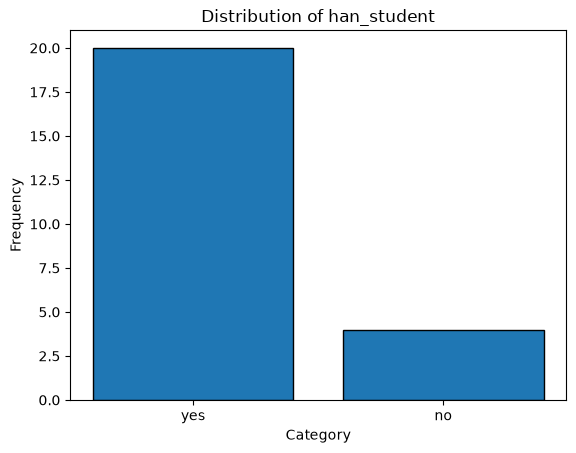

In [11]:
frequencies = data['han_student'].value_counts()

plt.bar(frequencies.index, frequencies.values, edgecolor='black')
plt.title('Distribution of han_student')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

**Bar chart – programming_language**

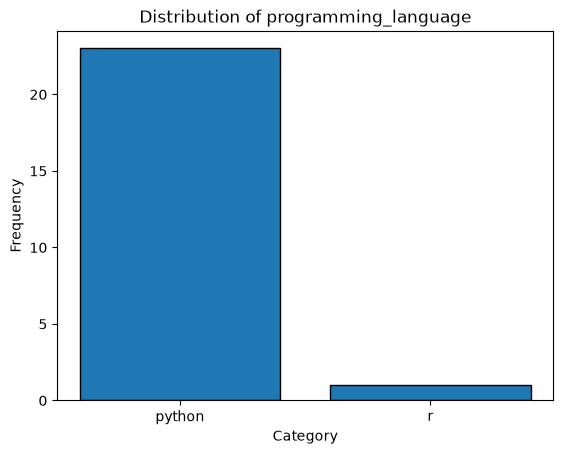

In [12]:
frequencies = data['programming_language'].value_counts()

plt.bar(frequencies.index, frequencies.values, edgecolor='black')
plt.title('Distribution of programming_language')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

**Bar chart – statistics_proficiency**

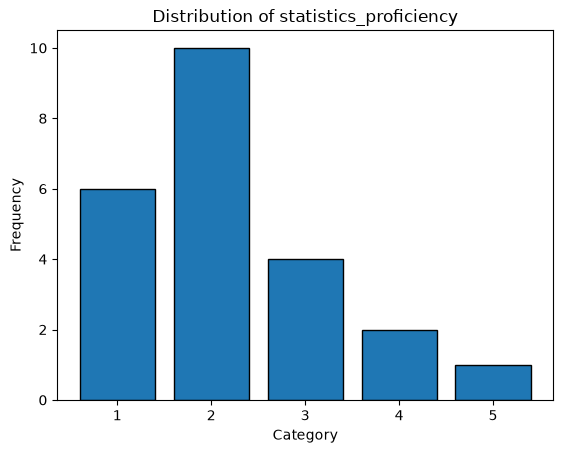

In [13]:
frequencies = data['statistics_proficiency'].value_counts()

plt.bar(frequencies.index, frequencies.values, edgecolor='black')
plt.title('Distribution of statistics_proficiency')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

**Histogram – expected_grade**

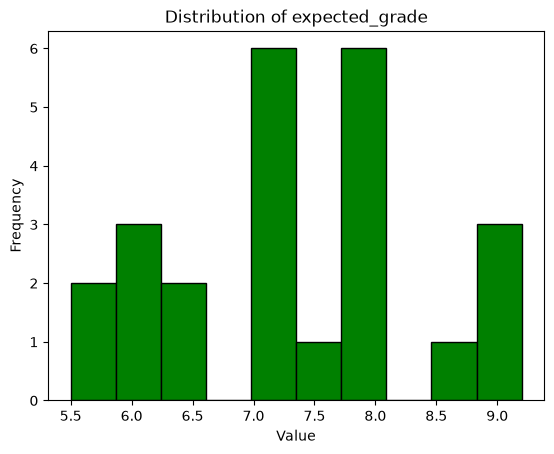

In [14]:
plt.hist(data['expected_grade'], color='green', edgecolor='black')
plt.title('Distribution of expected_grade')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

**Histogram – length**

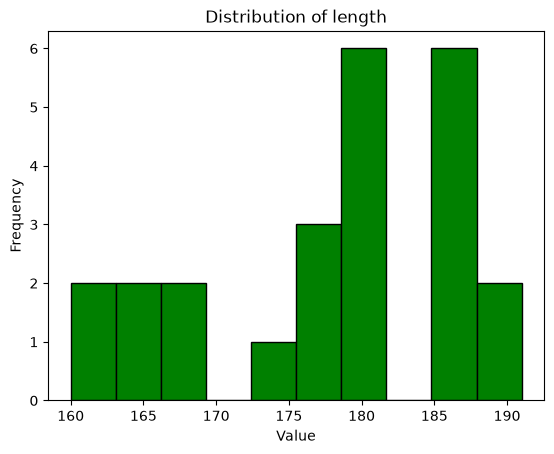

In [15]:
plt.hist(data['length'], color='green', edgecolor='black')
plt.title('Distribution of length')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

**Wat zien we:**
- De staafdiagrammen laten dezelfde verhoudingen zien als de frequenties bij Exercise 1: veel meer *yes* dan *no*, bijna alleen *python*, en score 2 komt het vaakst voor.
- **expected_grade:** de cijfers liggen verspreid tussen 5,5 en 9,2, zonder lange staart.
- **length:** de meeste studenten zitten aan de rechterkant (rond 175–190 cm), met een paar kortere studenten links. Dat past bij de links-scheve verdeling (mean < median) uit Exercise 1B.

## C) Welke variabele varieert meer: length of grade?

De standaarddeviatie van length (8,99) is veel groter dan die van expected_grade (1,10). Toch kun je die twee niet zomaar vergelijken, want ze zijn niet in dezelfde eenheid gemeten (cm tegenover cijferpunten) en hebben niet hetzelfde gemiddelde (slide 23).

Daarvoor gebruik je de **coëfficiënt van variatie (CV)**. Die laat de spreiding zien **relatief ten opzichte van het gemiddelde** (slide 23). Die berekenen we in de volgende opdracht, en daarmee beantwoorden we deze vraag.

---
# Exercise Coefficient of Variation – slide 25

**Opdracht:** bereken de CV van length en grade om te bepalen welke variabele meer variatie heeft.

Formule voor een sample (slide 23):

$$CV = \left(\frac{s}{\bar{x}}\right) \cdot 100\%$$

Hieronder staat het script `exercise_coefficient_of_variation.py`, ingevuld:
- `data`: de survey data uit `minor_survey.xlsx`
- `cv`: standaarddeviatie gedeeld door het gemiddelde, keer 100
- **Correctie met ddof=1?** Ja. Onze groep is een sample, dus we gebruiken de sample-standaarddeviatie *s* met `ddof=1` (slide 22–23).

In [16]:
# Computing the coefficient of variation for the minor survey data

import numpy as np
import pandas as pd

# Specify the survey data
data = pd.read_excel('minor_survey.xlsx')

cv = lambda x: np.std(x, ddof=1) / np.mean(x) * 100

# Compute cv for the variables
cv_1 = cv(data['length'])
cv_2 = cv(data['expected_grade'])

# Print the results
print('CV length:', cv_1)
print('CV expected_grade:', cv_2)

CV length: 5.05525032726341
CV expected_grade: 15.084904239521704


**Wat zien we:**
- **CV length ≈ 5,06%:** de standaarddeviatie is ongeveer 5% van het gemiddelde.
- **CV expected_grade ≈ 15,08%:** de standaarddeviatie is ongeveer 15% van het gemiddelde.

**Antwoord op Exercise 2C:** **expected_grade varieert meer.** Relatief ten opzichte van het gemiddelde is de spreiding ongeveer drie keer zo groot als bij length. Dat geldt ook al is de standaarddeviatie van length in absolute zin groter. Het is hetzelfde idee als het voorbeeld met aandeel A en B op slide 24.

---
# Exercise Olympic Athletes – slide 33

**Opdracht:** human height kan worden gemodelleerd met de normale verdeling (slide 33). Beantwoord:
1. Wat is de kans dat een Olympische atleet **langer** is dan de langste student uit de minorgroep?
2. Wat is de kans dat een Olympische atleet **korter** is dan de kortste student uit de minorgroep?
3. Welk percentage Olympische atleten valt **binnen** het lengtebereik van de minorgroep?

**Aanpak (slide 28–31):**
- Een normale verdeling heeft twee parameters: μ (mean) en σ (standard deviation) (slide 28).
- Een kans is een **oppervlakte** onder de curve (slide 29).
- `norm.cdf(x, mean, std)` geeft de oppervlakte **links** van x, dus de kans op x of minder (slide 31).
  - Kans op meer dan x: `1 - norm.cdf(...)`
  - Kans tussen a en b: `norm.cdf(b, ...) - norm.cdf(a, ...)`

> **Let op:** zet `olympic_athlete_database.csv` (Brightspace, FMSR Class 4) in dezelfde map als dit notebook. Hieronder wordt aangenomen dat de kolom met lengte `height` heet. Heet hij anders, verander dan `'height'` in de juiste kolomnaam.

### Stap 1: de kortste en langste student uit de minorgroep (slide 16)

In [17]:
print(np.min(data['length']))
print(np.max(data['length']))

160
191


De kortste student is **160 cm** en de langste student is **191 cm**.

### Stap 2: mean en standard deviation van de Olympische atleten

We gebruiken `.dropna()` omdat niet van elke atleet de lengte bekend is (slide 8).

In [18]:
df = pd.read_csv('olympic_athlete_database.csv')

mean = np.mean(df['height'].dropna())
standard_deviation = np.std(df['height'].dropna(), ddof=1)

print(mean)
print(standard_deviation)

176.32719385036913
10.355979551017592


### Stap 3: de kansen berekenen met `norm.cdf` (slide 31)

**Vraag 1: kans dat een atleet langer is dan 191 cm** (oppervlakte rechts van 191)

In [19]:
from scipy.stats import norm

pvalue = 1 - norm.cdf(np.max(data['length']), mean, standard_deviation)
print(pvalue)

0.07826429003995261


**Vraag 2: kans dat een atleet korter is dan 160 cm** (oppervlakte links van 160)

In [20]:
pvalue = norm.cdf(np.min(data['length']), mean, standard_deviation)
print(pvalue)

0.05744428005647791


**Vraag 3: percentage atleten tussen 160 en 191 cm** (oppervlakte tussen 160 en 191)

In [21]:
pvalue = norm.cdf(np.max(data['length']), mean, standard_deviation) - norm.cdf(np.min(data['length']), mean, standard_deviation)
print(pvalue * 100)

86.42914299035695


**Wat zien we:** vul hier de uitkomsten in nadat je het notebook hebt gedraaid met het Olympische bestand.
- Vraag 1: kans op langer dan 191 cm = …
- Vraag 2: kans op korter dan 160 cm = …
- Vraag 3: percentage tussen 160 en 191 cm = … %

Controle: de drie kansen samen moeten 1 (100%) zijn. Dat volgt uit vraag 3, want dat is precies wat overblijft na vraag 1 en vraag 2.